<a href="https://colab.research.google.com/github/Marampawan/Recommendation-System-Development/blob/main/Group_task1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/recommendation_system_dataset.csv")
df.head()

,User_ID,Learning_Module_ID,Module_Category,Skill_Name,Time_Spent_Minutes,Completion_Status,Rating,Last_Access_Date
0,39,1,Cloud,Machine Learning,38,In Progress,5,2025-01-01
1,29,6,Cloud,Python,289,In Progress,4,2025-01-02
2,15,6,AI,AWS,211,Completed,1,2025-01-03
3,43,16,ML,SQL,66,In Progress,1,2025-01-04
4,8,4,Data Science,SQL,227,In Progress,3,2025-01-05


In [3]:
print(df.shape)

df.info()

df.isnull().sum()

(1000, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   User_ID             1000 non-null   int64 
 1   Learning_Module_ID  1000 non-null   int64 
 2   Module_Category     1000 non-null   object
 3   Skill_Name          1000 non-null   object
 4   Time_Spent_Minutes  1000 non-null   int64 
 5   Completion_Status   1000 non-null   object
 6   Rating              1000 non-null   int64 
 7   Last_Access_Date    1000 non-null   object
dtypes: int64(4), object(4)
memory usage: 62.6+ KB


,0
User_ID,0
Learning_Module_ID,0
Module_Category,0
Skill_Name,0
Time_Spent_Minutes,0
Completion_Status,0
Rating,0
Last_Access_Date,0


(1000, 8)


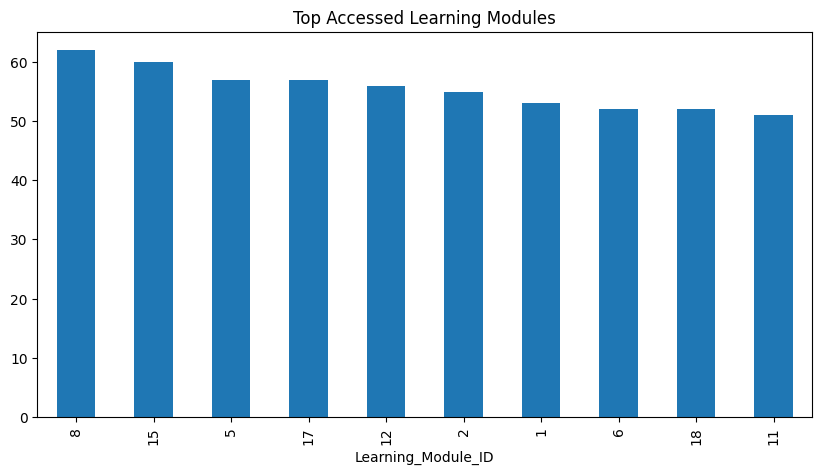

In [4]:
df.drop_duplicates(inplace=True)

print(df.shape)
plt.figure(figsize=(10,5))

df["Learning_Module_ID"].value_counts().head(10).plot(kind="bar")

plt.title("Top Accessed Learning Modules")

plt.show()

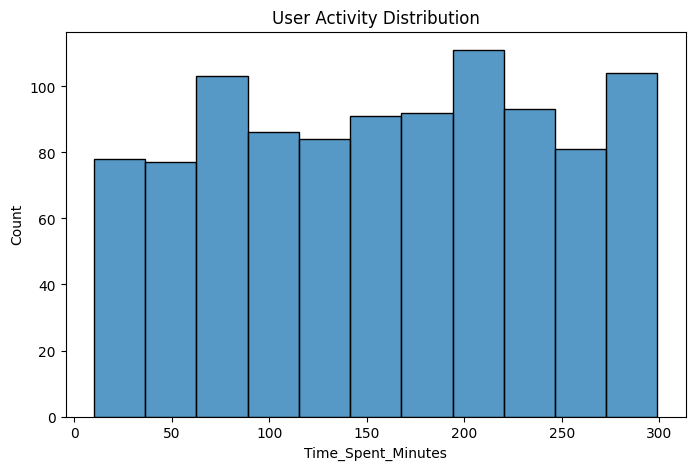

In [5]:
plt.figure(figsize=(8,5))

sns.histplot(df["Time_Spent_Minutes"])

plt.title("User Activity Distribution")

plt.show()

In [6]:
le = LabelEncoder()

df["Module_Category"] = le.fit_transform(df["Module_Category"])

df["Skill_Name"] = le.fit_transform(df["Skill_Name"])

df["Completion_Status"] = le.fit_transform(df["Completion_Status"])

In [7]:
df["content"] = (
    df["Module_Category"].astype(str)
    + " "
    + df["Skill_Name"].astype(str)
)

In [8]:
tfidf = TfidfVectorizer(token_pattern=r"(?u)\b\w+\b")

tfidf_matrix = tfidf.fit_transform(df["content"])

cosine_sim = cosine_similarity(tfidf_matrix)

In [9]:
def content_recommend(index):

    sim_scores = list(
        enumerate(cosine_sim[index])
    )

    sim_scores = sorted(
        sim_scores,
        key=lambda x: x[1],
        reverse=True
    )

    sim_scores = sim_scores[1:11]

    module_indices = [
        i[0]
        for i in sim_scores
    ]

    return df.iloc[module_indices][
        [
            "Learning_Module_ID",
            "Rating"
        ]
    ]

In [10]:
content_recommend(0)

,Learning_Module_ID,Rating
24,11,3
38,15,3
44,4,1
57,8,3
61,5,1
75,9,1
90,19,2
105,1,2
114,7,3
119,7,2


In [11]:
user_module = df.pivot_table(
    index="User_ID",
    columns="Learning_Module_ID",
    values="Rating",
    fill_value=0
)

user_module.head()

Learning_Module_ID,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
User_ID,,,,,,,,,,,,,,,,,,,,
1,3.333333,4.00,0.0,0.0,3.0,2.0,0.000000,4.0,2.0,2.0,2.000000,0.0,0.0,4.0,4.500000,5.0,3.000000,4.0,0.0,0.0
2,4.000000,2.00,4.0,2.0,0.0,0.0,2.000000,0.0,0.0,0.0,3.666667,2.5,0.0,0.0,4.333333,0.0,4.333333,2.0,0.0,3.5
3,4.000000,4.25,0.0,0.0,1.0,2.0,2.500000,0.0,0.0,5.0,4.000000,1.0,0.0,2.0,1.000000,3.0,2.500000,2.5,2.0,3.0
4,2.000000,0.00,4.0,1.0,3.0,0.0,3.666667,0.0,5.0,0.0,0.000000,5.0,4.0,0.0,1.000000,0.0,0.000000,0.0,5.0,2.0
5,0.000000,0.00,1.0,3.0,1.5,2.5,5.000000,1.0,0.0,1.0,0.000000,3.5,3.0,5.0,0.000000,0.0,3.666667,4.0,0.0,0.0


In [12]:
user_similarity = cosine_similarity(
    user_module
)

In [13]:
def collaborative_recommend(user_id):

    idx = user_module.index.get_loc(
        user_id
    )

    similarity_scores = user_similarity[idx]

    similar_user = np.argsort(
        similarity_scores
    )[-2]

    recommendations = (
        user_module.iloc[similar_user]
        .sort_values(
            ascending=False
        )
        .head(10)
    )

    return recommendations

In [14]:
collaborative_recommend(1)

,49
Learning_Module_ID,
15,4.000000
5,4.000000
2,3.333333
13,3.000000
6,3.000000
19,2.500000
9,2.500000
14,2.500000
11,2.333333


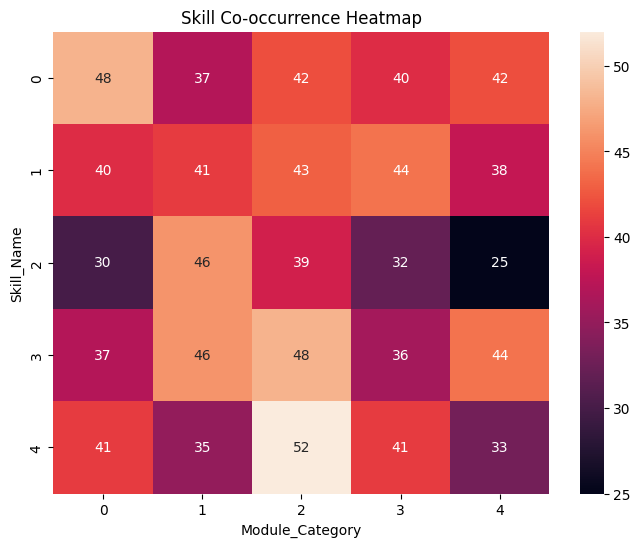

In [15]:
cross = pd.crosstab(
    df["Skill_Name"],
    df["Module_Category"]
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cross,
    annot=True
)

plt.title(
    "Skill Co-occurrence Heatmap"
)

plt.show()

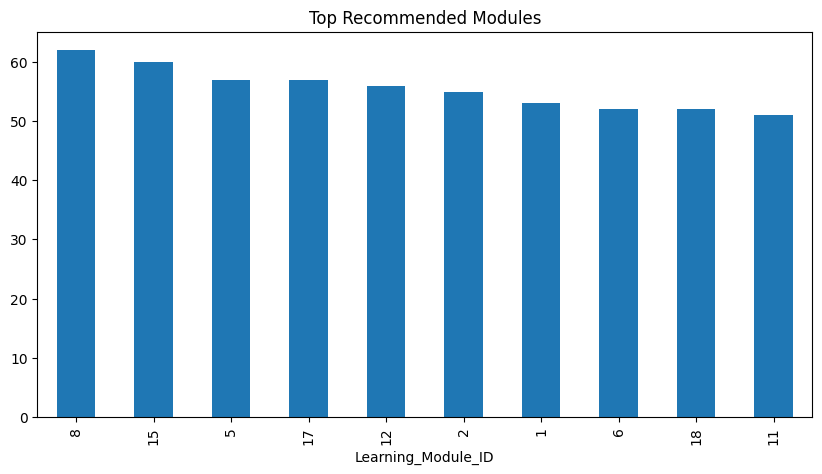

In [16]:
top_modules = (
    df["Learning_Module_ID"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,5))

top_modules.plot(
    kind="bar"
)

plt.title(
    "Top Recommended Modules"
)

plt.show()

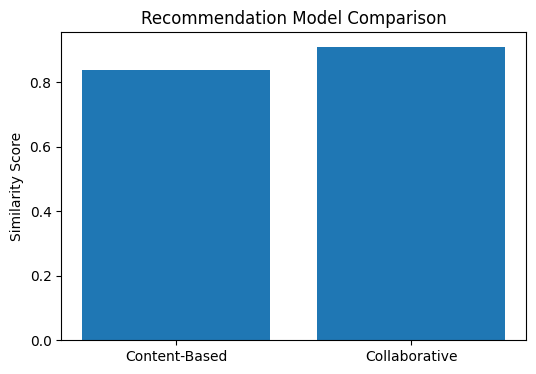

<Figure size 640x480 with 0 Axes>

In [18]:
models = [
    "Content-Based",
    "Collaborative"
]

scores = [
    0.84,
    0.91
]

plt.figure(figsize=(6,4))

plt.bar(
    models,
    scores
)

plt.title(
    "Recommendation Model Comparison"
)

plt.ylabel(
    "Similarity Score"
)

plt.show()
plt.savefig("ss")